[Feature](https://sp.ukdataservice.ac.uk/doc/6926/mrdoc/pdf/6926userguide.pdf)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')



In [2]:
df_5to7 = pd.read_csv('data/accidents_2005_to_2007.csv', dtype={'LSOA_of_Accident_Location': str})
df_9to11 = pd.read_csv('data/accidents_2009_to_2011.csv', dtype={'LSOA_of_Accident_Location': str})
df_12to14 = pd.read_csv('data/accidents_2012_to_2014.csv', dtype={'LSOA_of_Accident_Location': str})

df_aadf = pd.read_csv('data/ukTrafficAADF.csv')


df_5to7.head(5)

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [3]:
check = df_5to7.columns.equals(df_9to11.columns) and df_9to11.columns.equals(df_12to14.columns)

print(f"All files have the same features: {check}")

All files have the same features: True


In [4]:
df_total = pd.concat([df_5to7, df_9to11, df_12to14], ignore_index= True)

In [5]:
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 1504150 entries, 0 to 1504149
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1504150 non-null  str    
 1   Location_Easting_OSGR                        1504049 non-null  float64
 2   Location_Northing_OSGR                       1504049 non-null  float64
 3   Longitude                                    1504049 non-null  float64
 4   Latitude                                     1504049 non-null  float64
 5   Police_Force                                 1504150 non-null  int64  
 6   Accident_Severity                            1504150 non-null  int64  
 7   Number_of_Vehicles                           1504150 non-null  int64  
 8   Number_of_Casualties                         1504150 non-null  int64  
 9   Date                                         1504150 non-

In [6]:
df_total.isnull().sum()

Accident_Index                                       0
Location_Easting_OSGR                              101
Location_Northing_OSGR                             101
Longitude                                          101
Latitude                                           101
Police_Force                                         0
Accident_Severity                                    0
Number_of_Vehicles                                   0
Number_of_Casualties                                 0
Date                                                 0
Day_of_Week                                          0
Time                                               117
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
1st_Road_Class                                       0
1st_Road_Number                                      0
Road_Type                                            0
Speed_limit                                          0
Junction_D

We have many columns with **missing values**. I will check on each of them to see if the `NaN` are representing `None` or if they are missing



In [7]:
df = df_total.drop(columns= ['Junction_Detail'])

In [8]:
feat_to_check = ['Junction_Control', 'Pedestrian_Crossing-Human_Control',
                  'Pedestrian_Crossing-Physical_Facilities', 
                  'Weather_Conditions', 'Road_Surface_Conditions',
                  'Special_Conditions_at_Site', 'Carriageway_Hazards',
                  'Did_Police_Officer_Attend_Scene_of_Accident',
                  'LSOA_of_Accident_Location'
                ]


for ele in feat_to_check:
    print('\n' + ('=' * 40))
    print(f"Feature: {ele}")
    print('-' * 40)
    print(df[ele].value_counts(dropna=False))



Feature: Junction_Control
----------------------------------------
Junction_Control
Giveway or uncontrolled     733940
NaN                         602835
Automatic traffic signal    155717
Stop Sign                     9179
Authorised person             2479
Name: count, dtype: int64

Feature: Pedestrian_Crossing-Human_Control
----------------------------------------
Pedestrian_Crossing-Human_Control
None within 50 metres                 1495269
Control by other authorised person       5220
Control by school crossing patrol        3644
NaN                                        17
Name: count, dtype: int64

Feature: Pedestrian_Crossing-Physical_Facilities
----------------------------------------
Pedestrian_Crossing-Physical_Facilities
No physical crossing within 50 meters          1252571
Pedestrian phase at traffic signal junction     100248
non-junction pedestrian crossing                 79231
Zebra crossing                                   40106
Central refuge                    

Checking on the *location* features, let see if all four location-related columns have missing values in the exact same rows

In [9]:
loc_cols = ['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']

null_mask = df[loc_cols].isnull()
is_same = df[loc_cols].isnull().all(axis=1).eq(df[loc_cols].isnull().any(axis=1)).all()

print(f"Are all location missing values in the same rows? {is_same}")

Are all location missing values in the same rows? True


Good based on the analytics and the findings, we can set up the imputation as:

- `Junction_Control`, `Special_Conditions_at_Site`, `Carriageway_Hazards`: NaN has high proportion. They represents *None* in this case
  
- `Pedestrian_Crossing-Human_Control`, `Pedestrian_Crossing-Physical_Facilities`, `Weather_Conditions`, `Road_Surface_Conditions`, `Time`, `Latitude` has minor proportion of NaN values **(< 1%)**, we will just drop them

- `Did_Police_Officer_Attend_Scene_of_Accident`, `LSOA_of_Accident_Location` has a bit more, so we will impute them as **unknown**

In [10]:
fill_none_feat = [
    'Junction_Control', 'Special_Conditions_at_Site',
    'Carriageway_Hazards',
]

drop_na_feat = [
    'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities',
    'Weather_Conditions', 'Road_Surface_Conditions', 'Time', 'Latitude'
]

fill_unknown_feat = [
    'Did_Police_Officer_Attend_Scene_of_Accident',
    'LSOA_of_Accident_Location'
]

In [11]:
for ele in fill_none_feat:
    df[ele] = df[ele].fillna('None')

df = df.dropna(subset=drop_na_feat)

for ele in fill_unknown_feat:
    df[ele] = df[ele].fillna('Unknown')

In [12]:
df.isnull().sum()

Accident_Index                                 0
Location_Easting_OSGR                          0
Location_Northing_OSGR                         0
Longitude                                      0
Latitude                                       0
Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Date                                           0
Day_of_Week                                    0
Time                                           0
Local_Authority_(District)                     0
Local_Authority_(Highway)                      0
1st_Road_Class                                 0
1st_Road_Number                                0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
2nd_Road_Number     

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 1501819 entries, 0 to 1504149
Data columns (total 32 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1501819 non-null  str    
 1   Location_Easting_OSGR                        1501819 non-null  float64
 2   Location_Northing_OSGR                       1501819 non-null  float64
 3   Longitude                                    1501819 non-null  float64
 4   Latitude                                     1501819 non-null  float64
 5   Police_Force                                 1501819 non-null  int64  
 6   Accident_Severity                            1501819 non-null  int64  
 7   Number_of_Vehicles                           1501819 non-null  int64  
 8   Number_of_Casualties                         1501819 non-null  int64  
 9   Date                                         1501819 non-null 

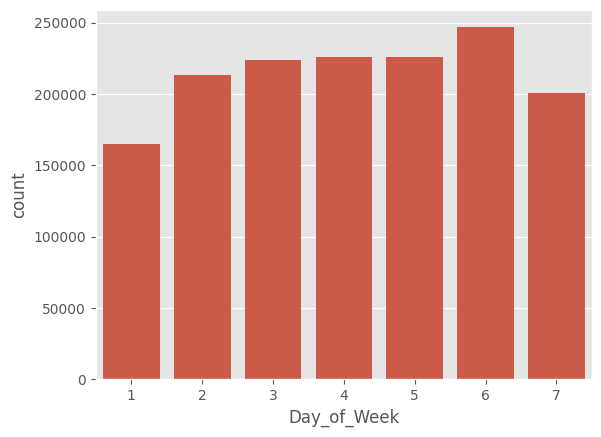

In [14]:
sns.countplot(df, x= 'Day_of_Week')
plt.show()

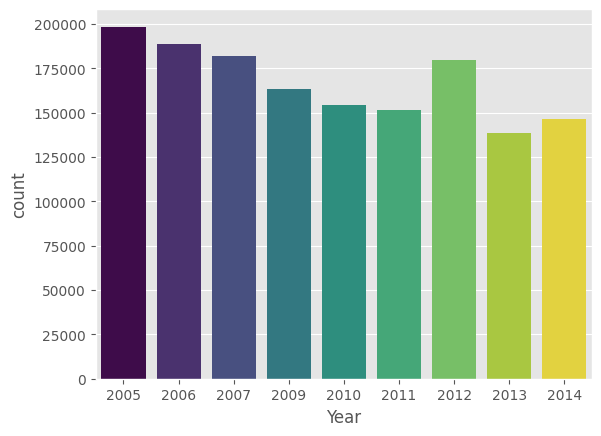

In [15]:

sns.countplot(data=df, x='Year', hue='Year', palette='viridis', legend=False)

plt.show()

In [16]:
df['Time'] = pd.to_datetime(df['Time'])
df['Hour'] = df['Time'].dt.hour

C:\Users\ducth\AppData\Local\Temp\ipykernel_15384\113868986.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


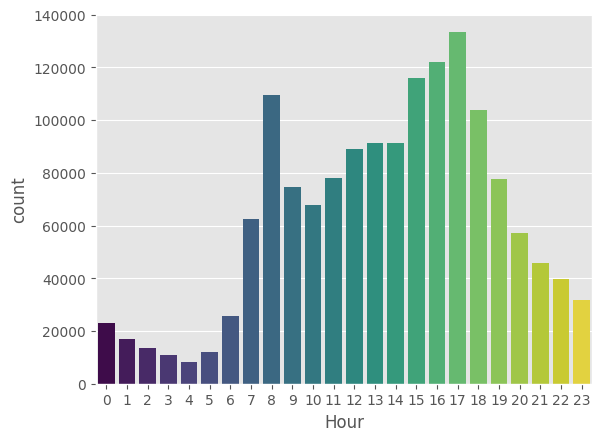

In [17]:
sns.countplot(data=df, x='Hour', hue='Hour', palette='viridis', legend=False)
plt.show()

In [18]:
df['LSOA_of_Accident_Location'].unique()

<ArrowStringArray>
['E01002849', 'E01002909', 'E01002857', 'E01002840', 'E01002863', 'E01002832',
 'E01002875', 'E01002889', 'E01002900', 'E01002835',
 ...
 'E01032691', 'E01032706', 'E01032712', 'E01032708', 'W01001596', 'W01001919',
 'W01001944', 'W01001948', 'W01001914', 'W01001921']
Length: 35453, dtype: str

In [19]:
import geopandas as gpd
from shapely.geometry import Point

districts = gpd.read_file('Data/lsoa.geojson')

geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf_accidents = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

districts = districts.to_crs("EPSG:4326")

df_mapped = gpd.sjoin(gdf_accidents, districts, how="left", predicate="within")

print(df_mapped.head())

  Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  Longitude  \
0  200501BS00001               525680.0                178240.0  -0.191170   
1  200501BS00002               524170.0                181650.0  -0.211708   
2  200501BS00003               524520.0                182240.0  -0.206458   
3  200501BS00004               526900.0                177530.0  -0.173862   
4  200501BS00005               528060.0                179040.0  -0.156618   

    Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  51.489096             1                  2                   1   
1  51.520075             1                  3                   1   
2  51.525301             1                  3                   2   
3  51.482442             1                  3                   1   
4  51.495752             1                  3                   1   

   Number_of_Casualties        Date  ...  objectid    lad16cd  \
0                     1  04/01/2005  ...     313.0 

In [20]:
df_mapped.isnull().sum()


Accident_Index                                    0
Location_Easting_OSGR                             0
Location_Northing_OSGR                            0
Longitude                                         0
Latitude                                          0
Police_Force                                      0
Accident_Severity                                 0
Number_of_Vehicles                                0
Number_of_Casualties                              0
Date                                              0
Day_of_Week                                       0
Time                                              0
Local_Authority_(District)                        0
Local_Authority_(Highway)                         0
1st_Road_Class                                    0
1st_Road_Number                                   0
Road_Type                                         0
Speed_limit                                       0
Junction_Control                                  0
2nd_Road_Cla

In [21]:
df = df_mapped

In [22]:
import reverse_geocoder as rg

# Batch lookup - much faster than row-by-row
coords = list(zip(df['Latitude'], df['Longitude']))
results = rg.search(coords) 

df['region'] = [r['admin2'] for r in results]
print(df['region'].value_counts())

Loading formatted geocoded file...
region
Greater London      228484
Kent                 45603
Surrey               37677
Lancashire           36465
Essex                34057
                     ...  
Clackmannanshire       747
Eilean Siar            328
Shetland Islands       310
Orkney Islands         236
Isles of Scilly         19
Name: count, Length: 174, dtype: int64


In [23]:
df['greater_region'] = [r['admin1'] for r in results]


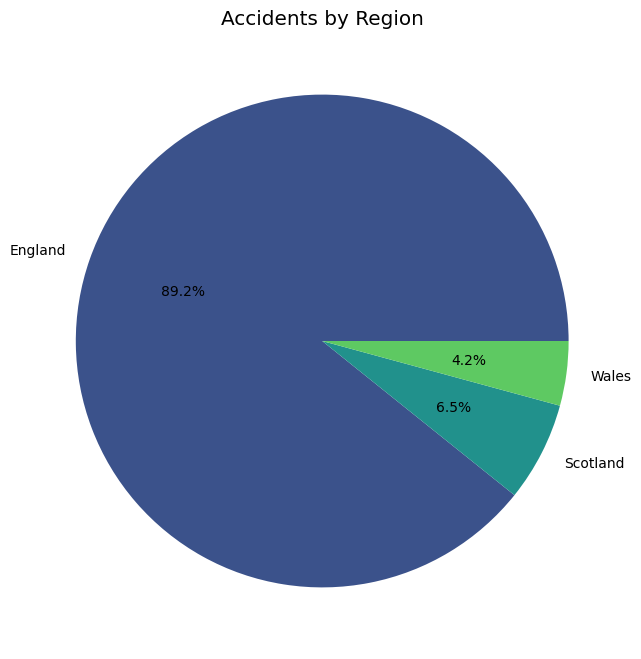

In [24]:
df['greater_region'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(8, 8),
    colors=sns.color_palette('viridis', df['greater_region'].nunique())
)
plt.ylabel('')
plt.title('Accidents by Region')
plt.show()

In [25]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1501819 entries, 0 to 1504149
Data columns (total 47 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1501819 non-null  str           
 1   Location_Easting_OSGR                        1501819 non-null  float64       
 2   Location_Northing_OSGR                       1501819 non-null  float64       
 3   Longitude                                    1501819 non-null  float64       
 4   Latitude                                     1501819 non-null  float64       
 5   Police_Force                                 1501819 non-null  int64         
 6   Accident_Severity                            1501819 non-null  int64         
 7   Number_of_Vehicles                           1501819 non-null  int64         
 8   Number_of_Casualties                         1501

In [26]:
region_lookup = pd.read_csv('Data/lad_to_region_en.csv')
region_lookup.info()

<class 'pandas.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   LAD16CD  326 non-null    str  
 1   LAD16NM  326 non-null    str  
 2   RGN16CD  326 non-null    str  
 3   RGN16NM  326 non-null    str  
 4   FID      326 non-null    int64
dtypes: int64(1), str(4)
memory usage: 25.8 KB


Here's how we link everything:

1. **Local_Authority_Districts_Dec_2016.geojson**: 
   - Convert `longtitude` and `latitude` to `lad16cd`

2. **[Uk Gov Look up](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-district-to-region-december-2016-lookup-in-en/about)**: 
   - Convert `lad16cd` to `rgn16NM`

In [27]:
region_lookup = region_lookup[['LAD16CD', 'RGN16NM']].drop_duplicates()

df = df.merge(
    region_lookup,
    left_on='lad16cd',
    right_on='LAD16CD',
    how='left'
)

print(df['RGN16NM'].value_counts())
print(f"\nTotal regions: {df['RGN16NM'].nunique()}")


RGN16NM
London                      230221
South East                  222855
North West                  183201
East of England             140206
Yorkshire and The Humber    135112
West Midlands               131699
South West                  123477
East Midlands               111722
North East                   60625
Name: count, dtype: int64

Total regions: 9


In [28]:
df.isnull().sum()

Accident_Index                                      0
Location_Easting_OSGR                               0
Location_Northing_OSGR                              0
Longitude                                           0
Latitude                                            0
Police_Force                                        0
Accident_Severity                                   0
Number_of_Vehicles                                  0
Number_of_Casualties                                0
Date                                                0
Day_of_Week                                         0
Time                                                0
Local_Authority_(District)                          0
Local_Authority_(Highway)                           0
1st_Road_Class                                      0
1st_Road_Number                                     0
Road_Type                                           0
Speed_limit                                         0
Junction_Control            

In [29]:
missing_mask = df['RGN16NM'].isna()
print(df[missing_mask]['lad16cd'].str[:3].value_counts())

lad16cd
S12    97554
W06    63736
Name: count, dtype: int64


In [30]:
df['RGN16NM'] = df['RGN16NM'].fillna(df['greater_region'])

# Sanity check - should be 0
print(df['RGN16NM'].isna().sum())

0


In [31]:
region_counts = df['RGN16NM'].value_counts()


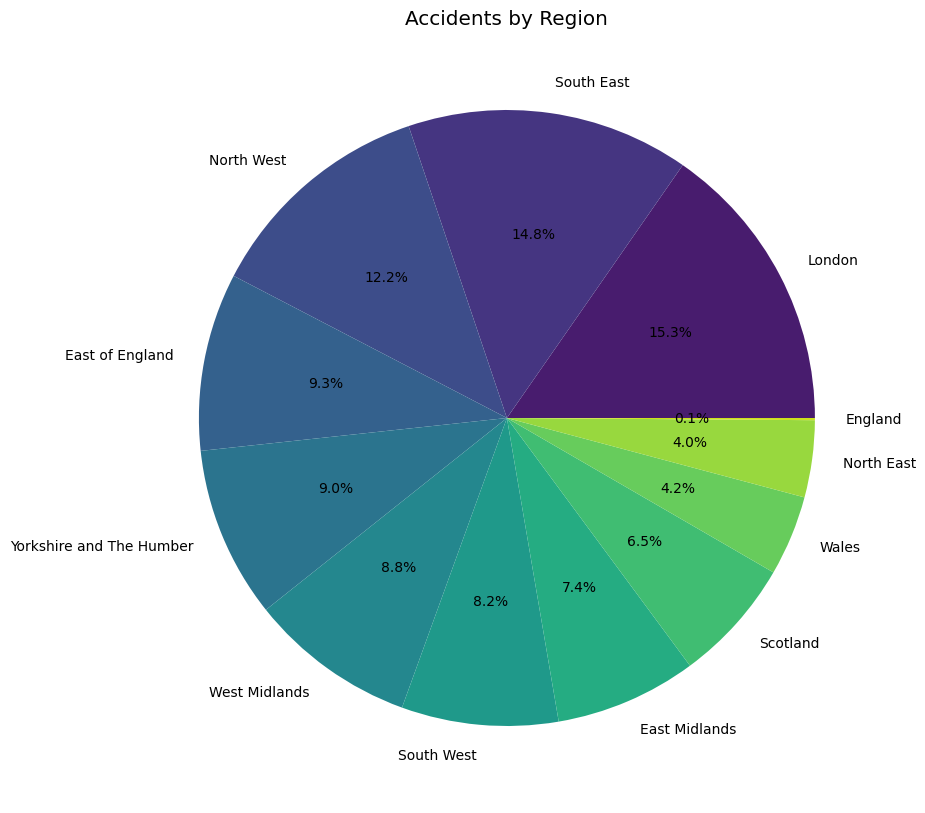

In [32]:
region_counts = df['RGN16NM'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(region_counts))
)
plt.title('Accidents by Region')
plt.show()

Geojson for regions: [Kaggle](https://www.kaggle.com/datasets/dorianlazar/uk-regions-geojson)

In [33]:
regions_geo = gpd.read_file('Data/uk_regions.geojson')
print(regions_geo['rgn19nm'].unique())  # adjust col name after seeing columns

<ArrowStringArray>
[              'North East',               'North West',
 'Yorkshire and the Humber',            'East Midlands',
            'West Midlands',                     'East',
                   'London',               'South East',
               'South West',         'Northern Ireland',
                 'Scotland',                    'Wales']
Length: 12, dtype: str


In [34]:
regions_geo['rgn19nm'] = regions_geo['rgn19nm'].replace({
    'East': 'East of England',
    'Yorkshire and the Humber': 'Yorkshire and The Humber'
})

In [35]:
region_counts = df['RGN16NM'].value_counts().reset_index()
region_counts.columns = ['RGN16NM', 'accident_count']

regions_geo = regions_geo.merge(
    region_counts,
    left_on='rgn19nm',
    right_on='RGN16NM',
    how='left'
)

# Sanity check - should be no NaN in accident_count
print(regions_geo[['rgn19nm', 'accident_count']])

                     rgn19nm  accident_count
0                 North East         60625.0
1                 North West        183201.0
2   Yorkshire and The Humber        135112.0
3              East Midlands        111722.0
4              West Midlands        131699.0
5            East of England        140206.0
6                     London        230221.0
7                 South East        222855.0
8                 South West        123477.0
9           Northern Ireland             NaN
10                  Scotland         97793.0
11                     Wales         63208.0


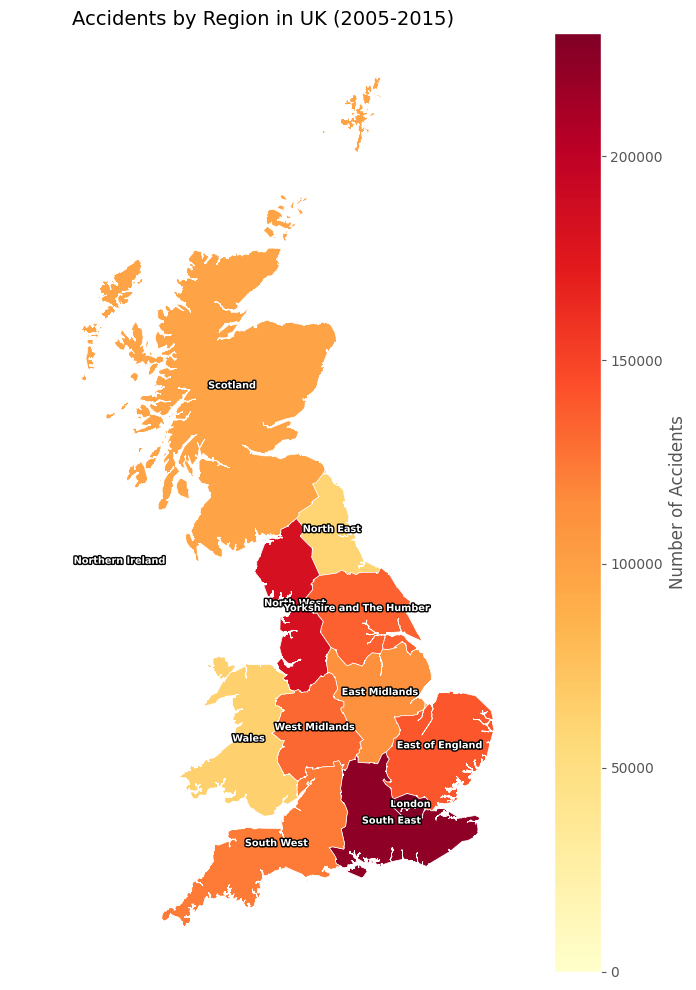

In [36]:
from matplotlib.patheffects import withStroke

fig, ax = plt.subplots(1, 1, figsize=(8, 10))
regions_geo.plot(
    column='accident_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor='white',
    linewidth=0.5,
    vmin=0,                                   # anchor 0 to the bottom of the scale
    vmax=regions_geo['accident_count'].max(),
    legend_kwds={'label': 'Number of Accidents'}
)

# Labels with outline effect for visibility
for _, row in regions_geo.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(
        row['rgn19nm'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=7, fontweight='bold', color='white',
        path_effects=[withStroke(linewidth=2, foreground='black')]  # outline
    )

ax.set_title('Accidents by Region in UK (2005-2015)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [37]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1501819 entries, 0 to 1501818
Data columns (total 49 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1501819 non-null  str           
 1   Location_Easting_OSGR                        1501819 non-null  float64       
 2   Location_Northing_OSGR                       1501819 non-null  float64       
 3   Longitude                                    1501819 non-null  float64       
 4   Latitude                                     1501819 non-null  float64       
 5   Police_Force                                 1501819 non-null  int64         
 6   Accident_Severity                            1501819 non-null  int64         
 7   Number_of_Vehicles                           1501819 non-null  int64         
 8   Number_of_Casualties                        

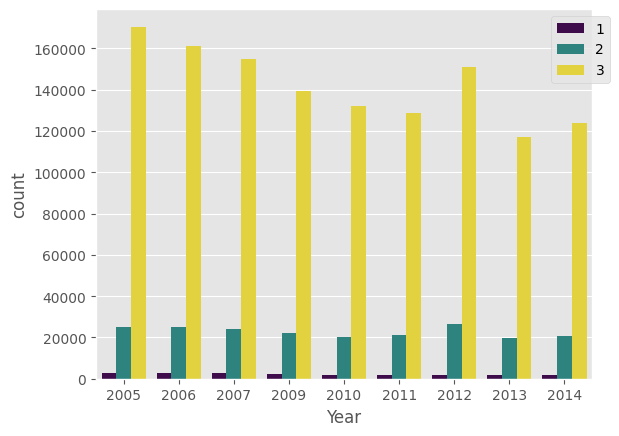

In [38]:
sns.countplot(df, hue = 'Accident_Severity', x = 'Year', palette= 'viridis')
plt.legend(bbox_to_anchor = [1.05, 1])
plt.show()

In [39]:
df['Accident_Severity_Label'] = df['Accident_Severity'].map({1: 'Fatal', 2: 'Serious', 3: 'Slight'})


In [40]:
df[df['RGN16NM'] == 'London']['Urban_or_Rural_Area'].value_counts()

Urban_or_Rural_Area
1    224404
2      5817
Name: count, dtype: int64

In [41]:
df['2nd_Road_Class'].unique()

array([-1,  5,  6,  4,  3,  1,  2])

In [42]:
df['1st_Road_Class'].unique()

array([3, 4, 5, 6, 1, 2])

In [43]:
df['Urban_or_Rural_Area_Label'] = df['Urban_or_Rural_Area'].map({1: 'Urban', 2: 'Rural'})

road_class_map = {-1: 'No second road', 1: 'Motorway', 2: 'A(M)', 3: 'A', 4: 'B', 5: 'C', 6: 'Unclassified'}

df['1st_Road_Class_Label'] = df['1st_Road_Class'].map(road_class_map)
df['2nd_Road_Class_Label'] = df['2nd_Road_Class'].map(road_class_map)

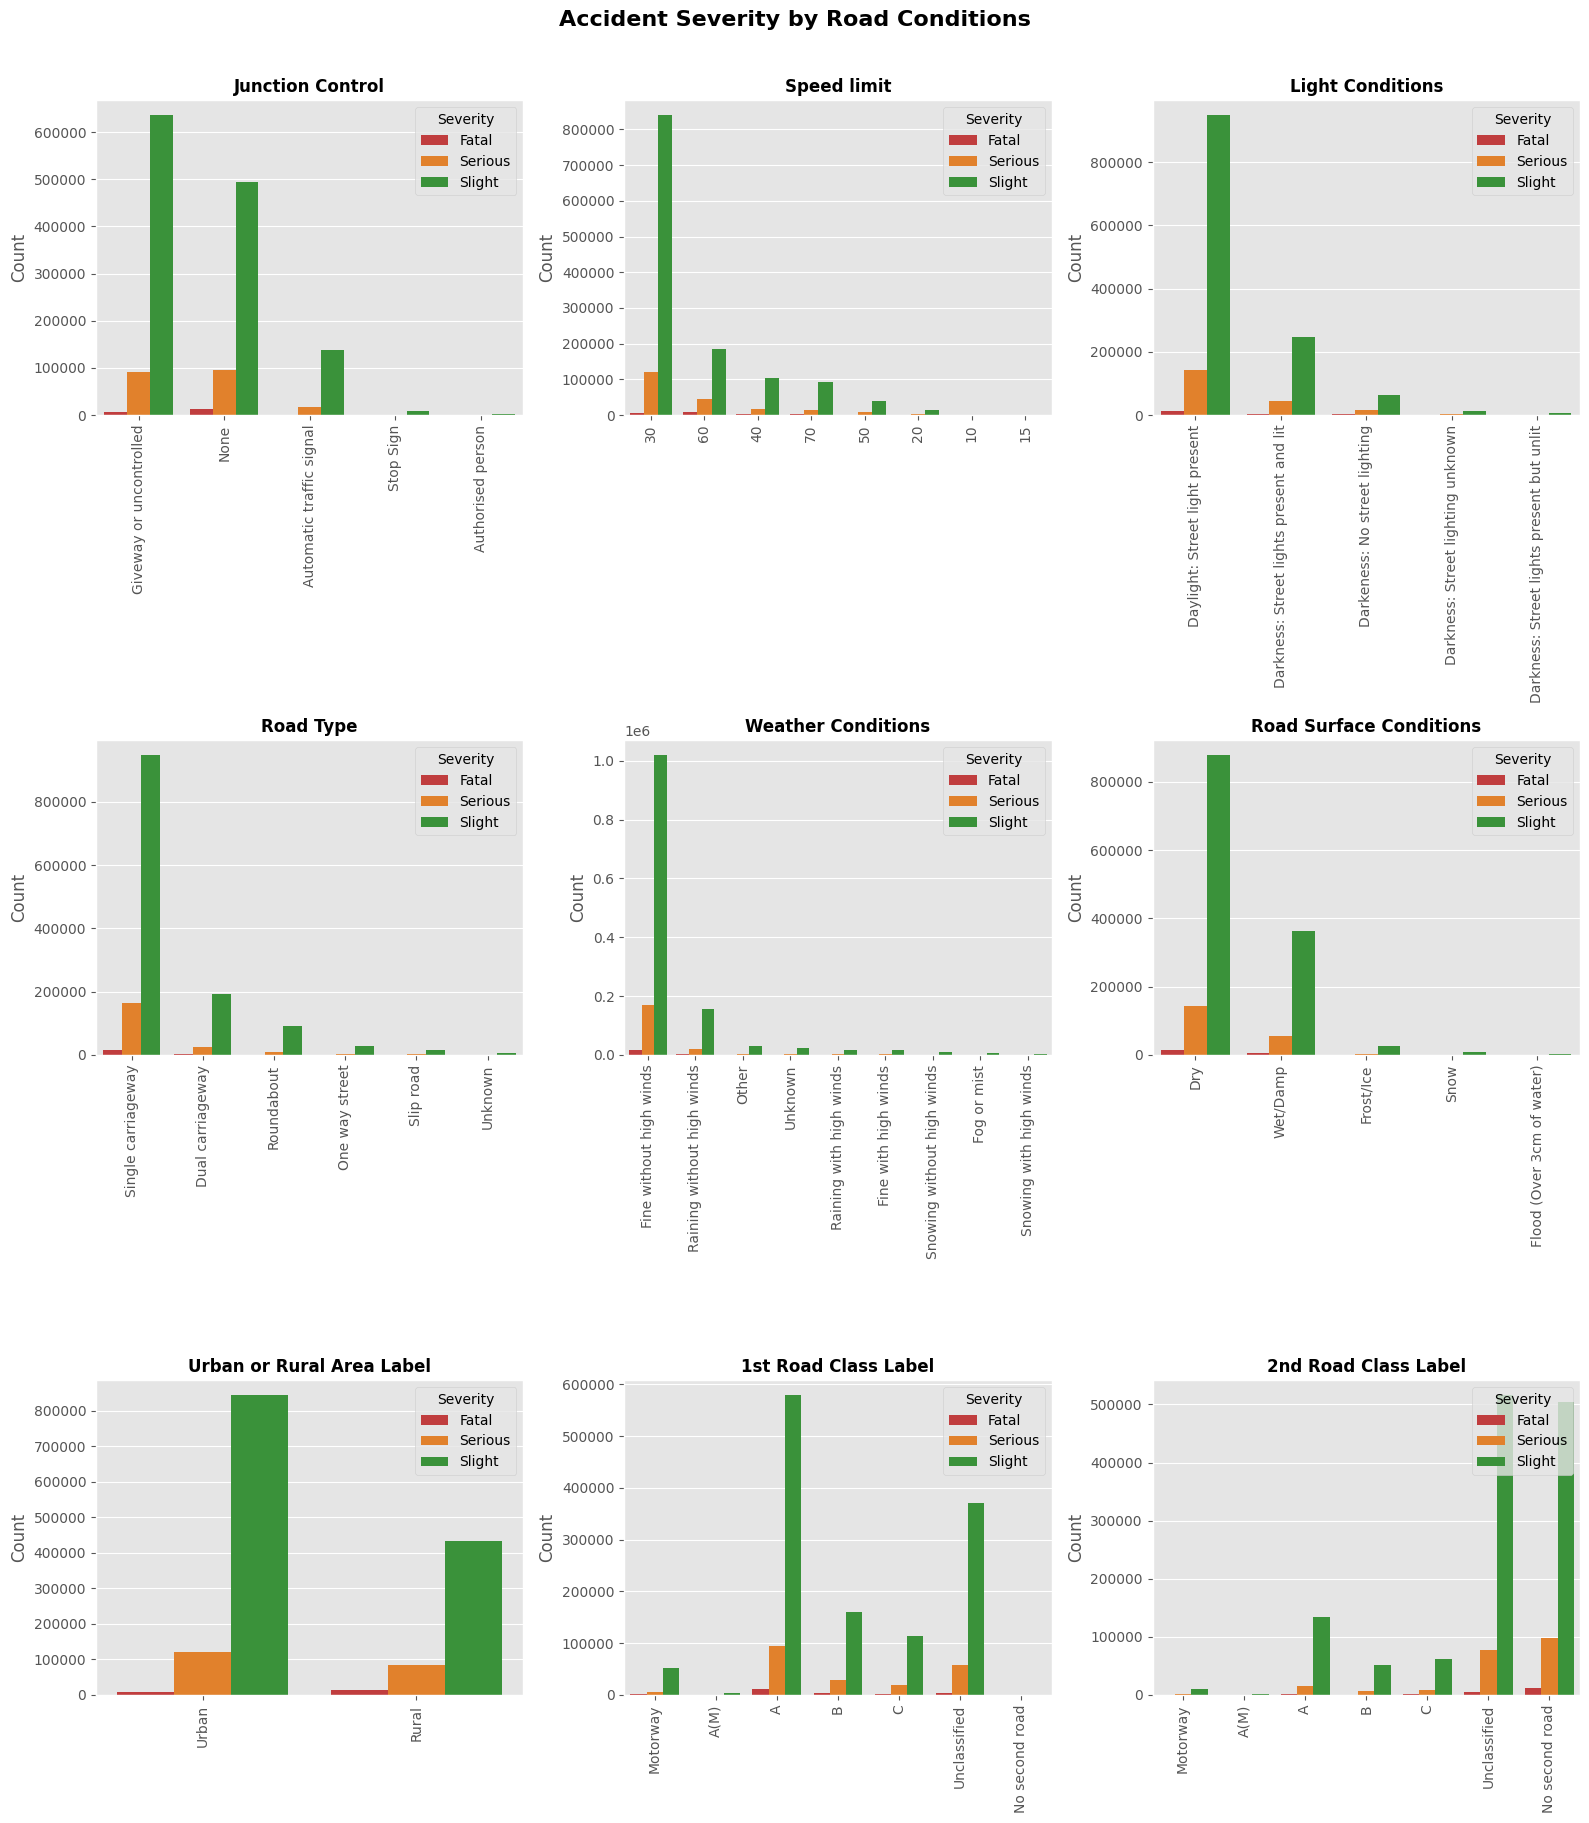

In [44]:

features = ['Junction_Control', 'Speed_limit', 'Light_Conditions', 'Road_Type',
            'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area_Label',
            '1st_Road_Class_Label', '2nd_Road_Class_Label'
            ]

severity_order = ['Fatal', 'Serious', 'Slight']
palette = {'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'}

road_order = ['Motorway', 'A(M)', 'A', 'B', 'C', 'Unclassified', 'No second road']

fig, axes = plt.subplots(3, 3, figsize=(16, 18))
axes = axes.flatten()



for i, col in enumerate(features):
    ax = axes[i]
    
    order = df[col].value_counts().index.tolist()
    order = road_order if 'Road_Class' in col else df[col].value_counts().index.tolist()
    sns.countplot(
        data=df,
        x=col,
        hue='Accident_Severity_Label',
        hue_order=severity_order,
        palette=palette,
        order=order,
        ax=ax
    )
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=90)
    ax.legend(title='Severity', loc='upper right')


plt.suptitle('Accident Severity by Road Conditions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [45]:
df_aadf.info()

<class 'pandas.DataFrame'>
RangeIndex: 275385 entries, 0 to 275384
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AADFYear                    275385 non-null  int64  
 1   CP                          275385 non-null  int64  
 2   Estimation_method           237812 non-null  str    
 3   Estimation_method_detailed  237812 non-null  str    
 4   Region                      275385 non-null  str    
 5   LocalAuthority              275385 non-null  str    
 6   Road                        275385 non-null  str    
 7   RoadCategory                275385 non-null  str    
 8   Easting                     275385 non-null  int64  
 9   Northing                    275385 non-null  int64  
 10  StartJunction               275129 non-null  str    
 11  EndJunction                 275147 non-null  str    
 12  LinkLength_km               275385 non-null  float64
 13  LinkLength_miles         

In [46]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1501819 entries, 0 to 1501818
Data columns (total 53 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1501819 non-null  str           
 1   Location_Easting_OSGR                        1501819 non-null  float64       
 2   Location_Northing_OSGR                       1501819 non-null  float64       
 3   Longitude                                    1501819 non-null  float64       
 4   Latitude                                     1501819 non-null  float64       
 5   Police_Force                                 1501819 non-null  int64         
 6   Accident_Severity                            1501819 non-null  int64         
 7   Number_of_Vehicles                           1501819 non-null  int64         
 8   Number_of_Casualties                        

In [47]:
cols_to_drop = [
    # Coordinate duplicates
    "Location_Easting_OSGR",
    "Location_Northing_OSGR",
    "bng_e",
    "bng_n",
    "long",
    "lat",
    # Spatial join artifacts
    "index_right",
    "objectid",
    "st_areashape",
    "st_lengthshape",
    # Duplicate admin columns
    "lad16nmw",  # Welsh name, duplicate of lad16nm
    "LAD16CD",   # incomplete (1.34M) duplicate of lad16cd (1.5M, fully complete)
    
    # geospartial
    'geometry',
    
]

df_accident = df.drop(columns=cols_to_drop).dropna().copy()
df_accident.isnull().sum()

Accident_Index                                 0
Longitude                                      0
Latitude                                       0
Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Date                                           0
Day_of_Week                                    0
Time                                           0
Local_Authority_(District)                     0
Local_Authority_(Highway)                      0
1st_Road_Class                                 0
1st_Road_Number                                0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
2nd_Road_Number                                0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-

In [48]:
df_accident['country'] = df_accident['greater_region']
df_accident['greater_region'] = df_accident['RGN16NM']
df_accident = df_accident.drop(columns=['RGN16NM'])

In [49]:
df_accident['greater_region'].unique()

<ArrowStringArray>
[                  'London',          'East of England',
               'South East',               'North West',
 'Yorkshire and The Humber',            'West Midlands',
            'East Midlands',                  'England',
                    'Wales',               'North East',
               'South West',                 'Scotland']
Length: 12, dtype: str

In [50]:
df_accident["Month"] = pd.to_datetime(df_accident["Date"], dayfirst=True).dt.month


In [51]:
import numpy as np
# Cyclical encode circular time features
for col, period in [("Hour", 24), ("Day_of_Week", 7), ("Month", 12)]:
    df_accident[f"{col}_sin"] = np.sin(2 * np.pi * df_accident[col] / period)
    df_accident[f"{col}_cos"] = np.cos(2 * np.pi * df_accident[col] / period)


In [52]:
df_accident.info()

<class 'pandas.DataFrame'>
Index: 1500400 entries, 0 to 1501818
Data columns (total 47 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1500400 non-null  str           
 1   Longitude                                    1500400 non-null  float64       
 2   Latitude                                     1500400 non-null  float64       
 3   Police_Force                                 1500400 non-null  int64         
 4   Accident_Severity                            1500400 non-null  int64         
 5   Number_of_Vehicles                           1500400 non-null  int64         
 6   Number_of_Casualties                         1500400 non-null  int64         
 7   Date                                         1500400 non-null  str           
 8   Day_of_Week                                  1500400 non-null  int64

In [53]:
# Run this to check
cols_to_check = [
    "Light_Conditions",
    "Weather_Conditions", 
    "Road_Surface_Conditions",
    "Special_Conditions_at_Site",
    "Carriageway_Hazards",
    "Junction_Control",
    "Pedestrian_Crossing-Human_Control",
    "Pedestrian_Crossing-Physical_Facilities",
    "Did_Police_Officer_Attend_Scene_of_Accident",
    "Road_Type",
]

for col in cols_to_check:
    print('\n' + '-' * 50)
    print(f"{col}: {df_accident[col].unique()}")


--------------------------------------------------
Light_Conditions: <ArrowStringArray>
[           'Daylight: Street light present',
   'Darkness: Street lights present and lit',
         'Darkness: Street lighting unknown',
 'Darkness: Street lights present but unlit',
             'Darkeness: No street lighting']
Length: 5, dtype: str

--------------------------------------------------
Weather_Conditions: <ArrowStringArray>
['Raining without high winds',    'Fine without high winds',
                    'Unknown', 'Snowing without high winds',
                      'Other',       'Fine with high winds',
    'Raining with high winds',                'Fog or mist',
    'Snowing with high winds']
Length: 9, dtype: str

--------------------------------------------------
Road_Surface_Conditions: <ArrowStringArray>
['Wet/Damp', 'Dry', 'Frost/Ice', 'Snow', 'Flood (Over 3cm of water)']
Length: 5, dtype: str

--------------------------------------------------
Special_Conditions_at_Site: <Ar

In [54]:
light_map = {
    'Daylight: Street light present': 1,
    'Daylight: No street lighting': 2,
    'Daylight: Street lighting unknown': 3,
    'Darkness: Street lights present and lit': 4,
    'Darkness: Street lights present but unlit': 5,
    'Darkness: No street lighting': 6,
    'Darkeness: No street lighting': 6,         # typo in data
    'Darkness: Street lighting unknown': 7,
}

weather_map = {
    'Fine without high winds': 1,
    'Raining without high winds': 2,
    'Snowing without high winds': 3,
    'Fine with high winds': 4,
    'Raining with high winds': 5,
    'Snowing with high winds': 6,
    'Fog or mist': 7,
    'Other': 8,
    'Unknown': 9,
}

road_surface_map = {
    'Dry': 1,
    'Wet/Damp': 2,
    'Snow': 3,
    'Frost/Ice': 4,
    'Flood (Over 3cm of water)': 5,
}

special_conditions_map = {
    'None': 0,
    'Auto traffic singal out': 1,               # typo in data
    'Auto traffic signal out': 1,
    'Auto traffic signal partly defective': 2,
    'Permanent sign or marking defective or obscured': 3,  # variant label
    'Road signs defective or obscured': 3,
    'Roadworks': 4,
    'Road surface defective': 5,
    'Ol or diesel': 6,                          # typo in data
    'Oil or diesel': 6,
    'Mud': 7,
}

carriageway_map = {
    'None': 0,
    'Dislodged vehicle load in carriageway': 1,
    'Other object in carriageway': 2,
    'Involvement with previous accident': 3,
    'Pedestrian in carriageway (not injured)': 6,
    'Any animal (except a ridden horse)': 7,    # variant label
    'Any animal in carriageway (except ridden horse)': 7,
}

junction_control_map = {
    'None': 0,
    'Authorised person': 1,
    'Automatic traffic signal': 2,
    'Stop Sign': 3,
    'Giveway or uncontrolled': 4,
}

ped_human_map = {
    'None within 50 metres': 0,
    'Control by school crossing patrol': 1,
    'Control by other authorised person': 2,
}

ped_physical_map = {
    'No physical crossing within 50 meters': 0,
    'Zebra crossing': 1,
    'non-junction pedestrian crossing': 4,
    'Pedestrian phase at traffic signal junction': 5,
    'Footbridge or subway': 7,
    'Central refuge': 8,
}

police_map = {
    'Yes': 1,
    'No': 2,
    'Unknown': 3,
}

road_type_map = {
    'Roundabout': 1,
    'One way street': 2,
    'Dual carriageway': 3,
    'Single carriageway': 6,
    'Slip road': 7,
    'Unknown': 9,
}

# Apply all mappings
mapping_cols = {
    'Light_Conditions': light_map,
    'Weather_Conditions': weather_map,
    'Road_Surface_Conditions': road_surface_map,
    'Special_Conditions_at_Site': special_conditions_map,
    'Carriageway_Hazards': carriageway_map,
    'Junction_Control': junction_control_map,
    'Pedestrian_Crossing-Human_Control': ped_human_map,
    'Pedestrian_Crossing-Physical_Facilities': ped_physical_map,
    'Did_Police_Officer_Attend_Scene_of_Accident': police_map,
    'Road_Type': road_type_map,
}

for col, mapping in mapping_cols.items():
    df_accident[f"{col}_code"] = df_accident[col].map(mapping)


Let's set up the features now, we leave out:
- `Did_Police_Officer_Attend_Scene_of_Accident_code`: Police response, does not affect risk
- `Police_Force`: ID, the are similar with locations
- `1st and 2nd Road Number`: They are just ID


In [55]:
cluster_features = [
    # Geo
    # "Latitude", "Longitude",

    # Risk
    "Accident_Severity",
    "Number_of_Vehicles",
    "Number_of_Casualties",

    # Road info
    "Speed_limit",
    "Urban_or_Rural_Area",
    "1st_Road_Class",
    "2nd_Road_Class",
    "Road_Type_code",
    "Junction_Control_code",

    # Environment
    "Light_Conditions_code",
    "Weather_Conditions_code",
    "Road_Surface_Conditions_code",
    "Special_Conditions_at_Site_code",
    "Carriageway_Hazards_code",

    # Pedestrian
    "Pedestrian_Crossing-Human_Control_code",
    "Pedestrian_Crossing-Physical_Facilities_code",

    # Temporal (cyclical) 
    "Hour_sin", "Hour_cos",
    "Day_of_Week_sin", "Day_of_Week_cos",
    "Month_sin", "Month_cos",
    "Year",  # linear

]

df_cluster = df_accident[cluster_features].copy()
print(f"Feature matrix shape: {df_cluster.shape}")  # (1500400, 25)

Feature matrix shape: (1500400, 23)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Scaled shape: {X_scaled.shape}")

Scaled shape: (1500400, 23)


k=2 done, inertia=31580025
k=3 done, inertia=29886831
k=4 done, inertia=28693322
k=5 done, inertia=28486564
k=6 done, inertia=26620195
k=7 done, inertia=26109945
k=8 done, inertia=25966043
k=9 done, inertia=24211861
k=10 done, inertia=24565140
k=11 done, inertia=22667916


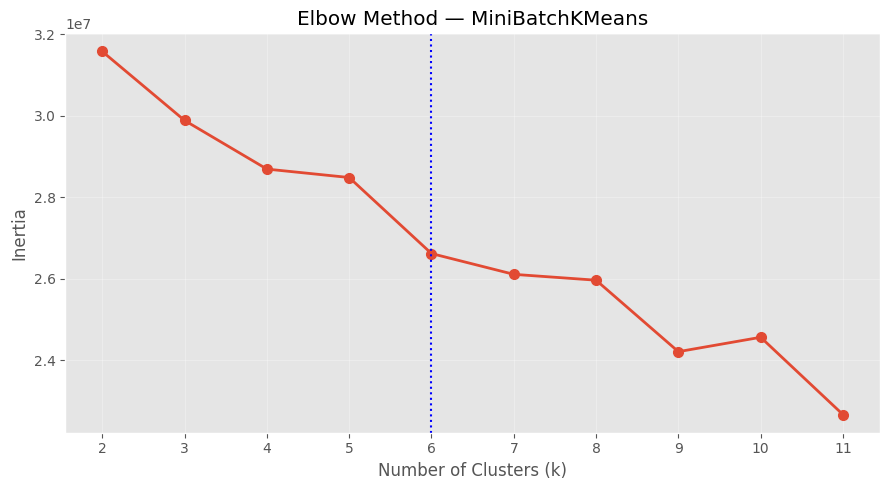

In [57]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from kneed import KneeLocator

inertias = []
k_range = range(2, 12)

for k in k_range:
    model = MiniBatchKMeans(n_clusters=k, random_state=8, batch_size=10_000, n_init=3)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    print(f"k={k} done, inertia={model.inertia_:.0f}")

kl = KneeLocator(k_range, inertias, curve= 'convex', direction= 'decreasing')
optimal_k = kl.elbow

# Plot
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=7)
plt.axvline(optimal_k, color = 'blue', linestyle = ':',
             label= f"Optimal k = {optimal_k}")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — MiniBatchKMeans")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Fit final model
kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=8, batch_size=10_000, n_init=3)
df_accident["cluster"] = kmeans.fit_predict(X_scaled)

# Check cluster sizes — watch for heavily imbalanced clusters
print(df_accident["cluster"].value_counts().sort_index())

# Profile each cluster
profile = df_accident.groupby("cluster")[cluster_features].mean().round(2)
print(profile.T)  # transpose so features are rows, clusters are columns

cluster
0    293600
1    524334
2    158299
3      8845
4    194893
5    320429
Name: count, dtype: int64
cluster                                             0        1        2  \
Accident_Severity                                2.72     2.87     2.91   
Number_of_Vehicles                               1.90     1.89     1.92   
Number_of_Casualties                             1.66     1.30     1.29   
Speed_limit                                     60.77    33.44    38.82   
Urban_or_Rural_Area                              1.93     1.22     1.30   
1st_Road_Class                                   3.09     4.51     3.66   
2nd_Road_Class                                  -0.28     5.53     4.58   
Road_Type_code                                   4.93     6.03     1.77   
Junction_Control_code                            0.58     3.87     3.71   
Light_Conditions_code                            2.69     1.74     1.77   
Weather_Conditions_code                          1.72     1.50     1.

In [59]:
cluster_labels = {
    0: "High-Speed Rural - Fatal Risk",      # 61mph, rural, 2.72 = most fatal skew
    1: "Urban Junction - Signalled",          # urban, signalled, moderate severity
    2: "Roundabout/Mixed - Low Severity",     # 2.91 = mostly slight
    3: "Pedestrian Zone - Patrol",            # school crossing patrol, tiny cluster
    4: "Urban Pedestrian Crossing",           # pelican/puffin crossings
    5: "Urban Non-Junction",                  # no junction, single road
}

df_accident["cluster_label"] = df_accident["cluster"].map(cluster_labels)
print(df_accident["cluster_label"].value_counts())

cluster_label
Urban Junction - Signalled         524334
Urban Non-Junction                 320429
High-Speed Rural - Fatal Risk      293600
Urban Pedestrian Crossing          194893
Roundabout/Mixed - Low Severity    158299
Pedestrian Zone - Patrol             8845
Name: count, dtype: int64


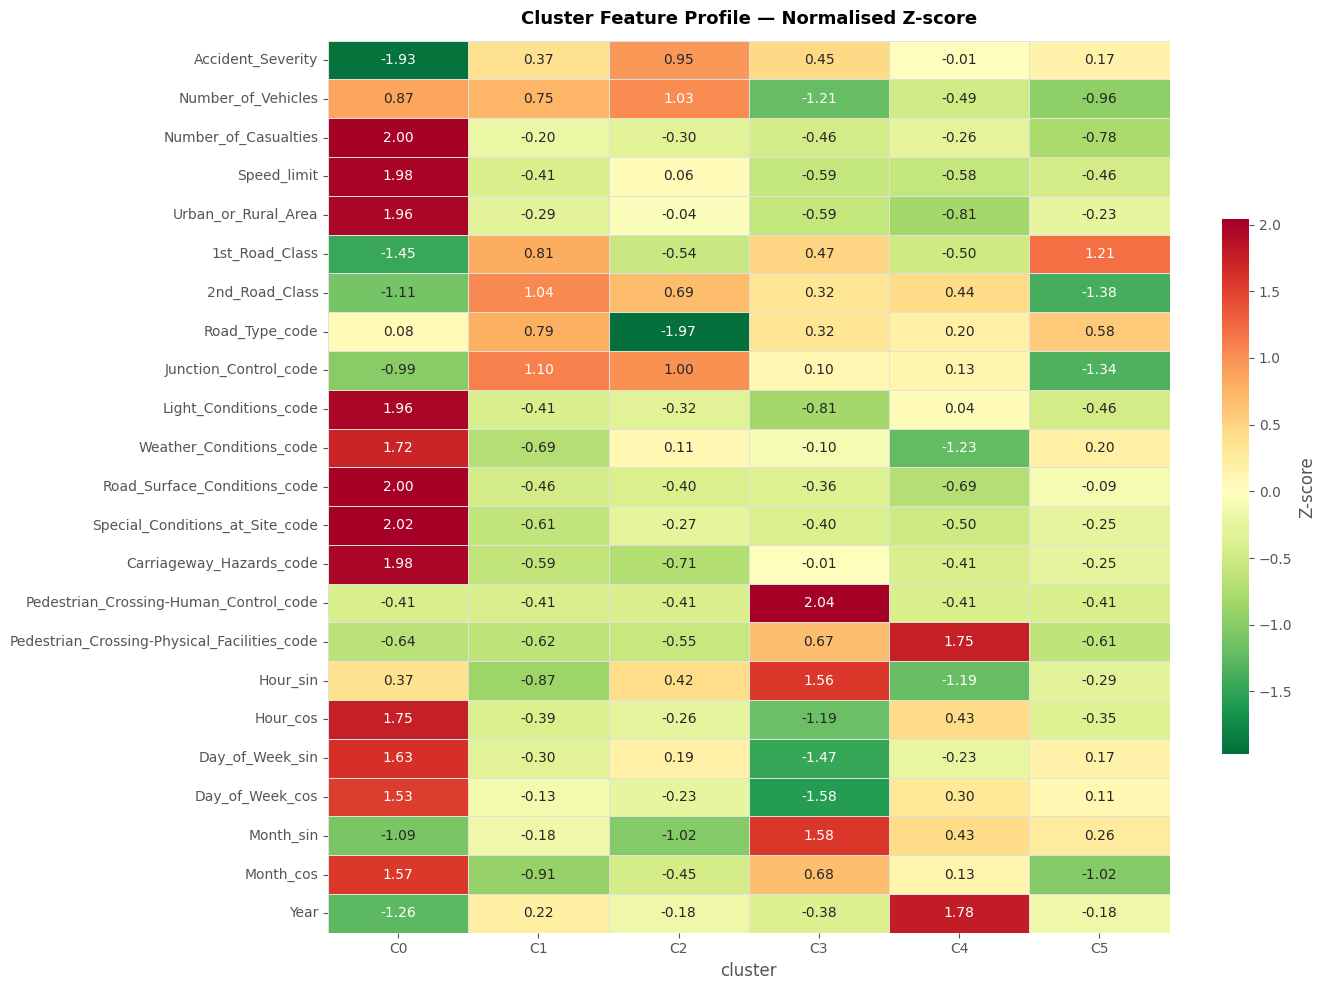

In [60]:
heatmap_features = [f for f in cluster_features if not f.startswith("greater_region")]
profile = df_accident.groupby("cluster")[heatmap_features].mean()
profile_norm = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    profile_norm.T,
    ax=ax,
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=True,
    fmt = '.2f',
    cbar_kws={"shrink": 0.6, "label": "Z-score"},
    xticklabels=[f"C{i}" for i in range(6)],
    yticklabels=heatmap_features,
)
ax.set_title("Cluster Feature Profile — Normalised Z-score", fontsize=13, fontweight="bold", pad=12)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

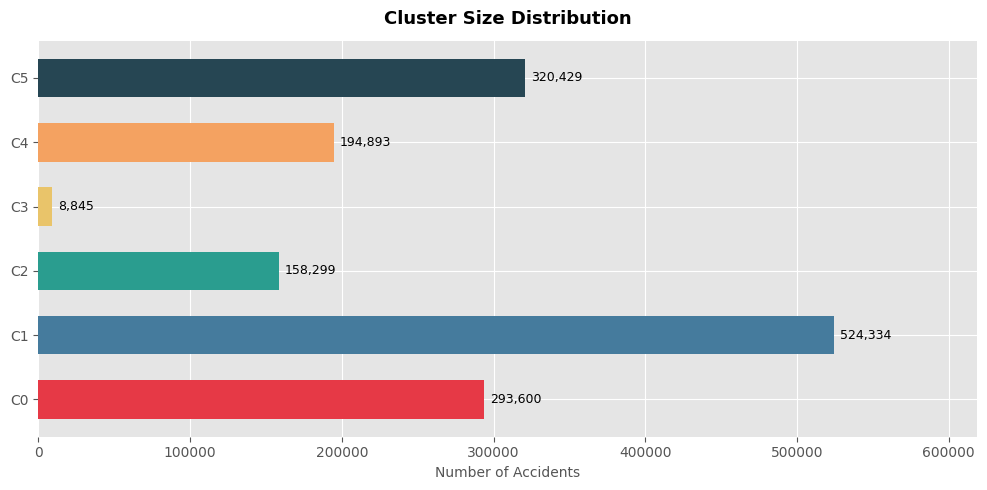

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))

cluster_colors = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653"]
sizes = df_accident["cluster"].value_counts().sort_index()
bars = ax.barh(
    [f"C{i}" for i in sizes.index],
    sizes.values,
    color=cluster_colors,
    edgecolor="none",
    height=0.6,
)
for bar, val in zip(bars, sizes.values):
    ax.text(
        bar.get_width() + 4000, bar.get_y() + bar.get_height() / 2,
        f"{val:,}", va="center", fontsize=9
    )
ax.set_title("Cluster Size Distribution", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Accidents", fontsize=10)
ax.spines[:].set_visible(False)
ax.set_xlim(0, sizes.max() * 1.18)
plt.tight_layout()
plt.show()

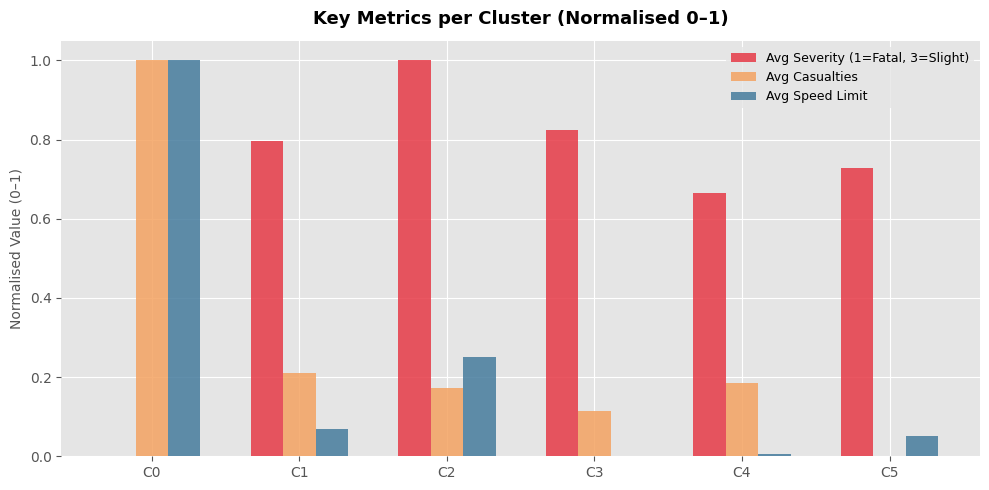

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics  = ["Accident_Severity", "Number_of_Casualties", "Speed_limit"]
m_labels = ["Avg Severity (1=Fatal, 3=Slight)", "Avg Casualties", "Avg Speed Limit"]
m_colors = ["#E63946", "#F4A261", "#457B9D"]
x        = np.arange(6)
width    = 0.22

for i, (metric, label, color) in enumerate(zip(metrics, m_labels, m_colors)):
    vals      = profile[metric].values
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min())
    ax.bar(x + i * width, vals_norm, width, label=label, color=color, alpha=0.85, edgecolor="none")

ax.set_title("Key Metrics per Cluster (Normalised 0–1)", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x + width)
ax.set_xticklabels([f"C{i}" for i in range(6)])
ax.set_ylabel("Normalised Value (0–1)", fontsize=10)
ax.legend(fontsize=9, edgecolor="none")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

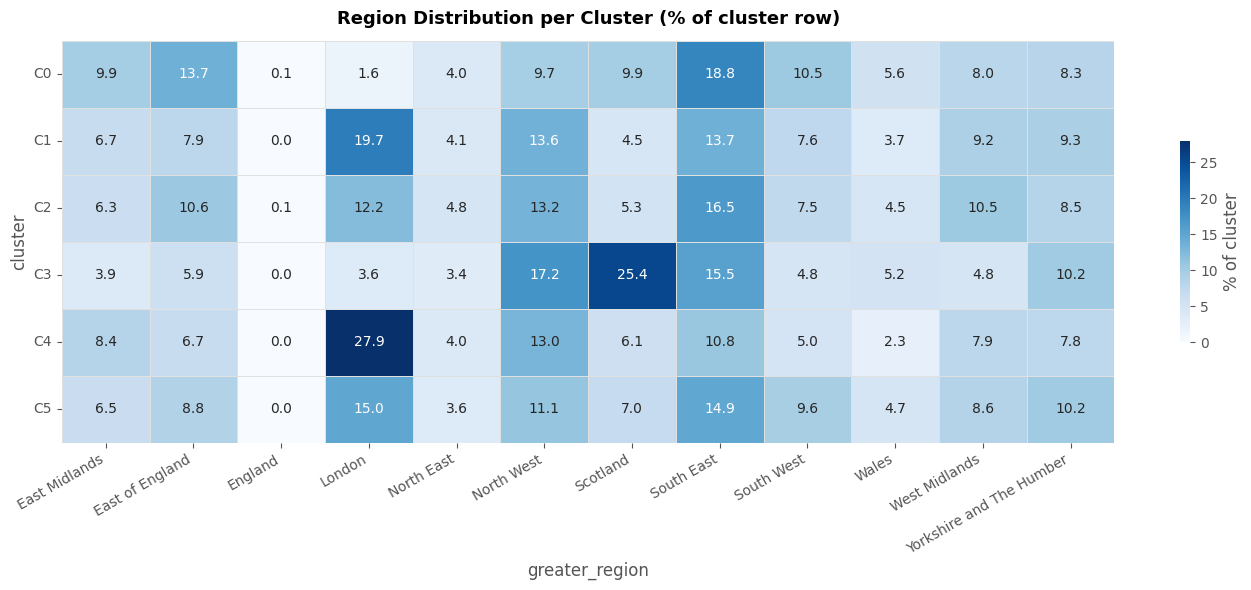

In [63]:
fig, ax = plt.subplots(figsize=(14, 6))

cross = pd.crosstab(
    df_accident["cluster"],
    df_accident["greater_region"],
    normalize="index"
).round(3) * 100

sns.heatmap(
    cross,
    ax=ax,
    cmap="Blues",
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=True,
    fmt=".1f",
    cbar_kws={"shrink": 0.5, "label": "% of cluster"},
    xticklabels=cross.columns,
    yticklabels=[f"C{i}" for i in cross.index],
)
ax.set_title("Region Distribution per Cluster (% of cluster row)", fontsize=13, fontweight="bold", pad=12)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 🚦 K-Means Clustering Analysis — UK Road Accidents (2005–2016)

### Overview
Using **MiniBatchKMeans** with **k=6** (selected via KneeLocator elbow method), 
1,500,400 accident records were segmented into 6 distinct risk profiles based on 
23 features spanning road geometry, environmental conditions, pedestrian 
infrastructure, and temporal patterns. All features were standardised using 
`StandardScaler` prior to clustering, with cyclical encoding applied to `Hour`, 
`Day_of_Week`, and `Month` to preserve their circular nature.

---

### Cluster Definitions

| Cluster | Label | Size | Severity (mean) | Casualties (mean) | Speed Limit (mean) |
|---|---|---|---|---|---|
| **C0** | High-Speed Rural — Fatal Risk | 293,600 | **2.72** | **1.66** | **60.8 mph** |
| **C1** | Urban Junction — Signalled | 524,334 | 2.87 | 1.30 | 33.4 mph |
| **C2** | Roundabout / Mixed Junction | 158,299 | 2.91 | 1.29 | 38.8 mph |
| **C3** | Pedestrian Zone — Patrol | 8,845 | 2.87 | 1.26 | 31.4 mph |
| **C4** | Urban Pedestrian Crossing | 194,893 | 2.84 | 1.29 | 31.6 mph |
| **C5** | Urban Non-Junction | 320,429 | 2.86 | 1.21 | 33.0 mph |

---

### Cluster-by-Cluster Interpretation

#### 🔴 C0 — High-Speed Rural (Fatal Risk)
The most dangerous cluster by every metric. With an average speed limit of 
**60.8 mph** and `Urban_or_Rural_Area` firmly in rural territory, these accidents 
occur on A-roads and Motorways far from urban infrastructure. The heatmap shows 
strongly elevated z-scores for `Speed_limit`, `Urban_or_Rural_Area`, 
`Number_of_Casualties`, `Light_Conditions_code`, `Road_Surface_Conditions_code`, 
`Carriageway_Hazards_code`, and `Special_Conditions_at_Site_code` — indicating 
these accidents disproportionately occur under adverse conditions on fast, open 
roads. The mean severity of **2.72** (closest to 1=Fatal) makes this the highest 
risk cluster, confirmed by the normalised bar chart where C0 scores maximum on 
both Speed and Casualties. Geographically, C0 is spread across all regions 
(~10% each) with a slight concentration in **South East (18.8%)** and 
**East of England (13.7%)**, consistent with high-speed A-road networks there.

#### 🔵 C1 — Urban Junction (Signalled)
The largest cluster at **524,334 accidents (35% of total)**. Characterised by 
low speed limits (~33 mph), urban roads, and high `Junction_Control_code` 
indicating traffic signal presence. The heatmap shows elevated `2nd_Road_Class` 
and `Road_Type_code`, confirming junction-based collisions at intersections. 
Severity is mild (2.87 ≈ mostly Slight). **London dominates at 19.7%**, 
consistent with its dense signalised junction network. This cluster represents 
the typical urban fender-bender scenario — high frequency, low severity.

#### 🟢 C2 — Roundabout / Mixed Junction
The **safest cluster** with severity 2.91 (most Slight). `Road_Type_code` 
z-score of **-1.97** is the most extreme value in the entire heatmap, firmly 
identifying roundabout geometry as the defining characteristic. Despite moderate 
speed limits (~39 mph), the inherent safety design of roundabouts (no 
perpendicular collisions) keeps severity low. Scotland (13.2%) and South East 
(16.5%) are slightly over-represented. This cluster supports the well-established 
road safety evidence that roundabouts reduce fatal collisions compared to 
signalised crossroads.

#### 🟡 C3 — Pedestrian Zone (School Patrol)
The **smallest and most distinctive cluster** at just **8,845 accidents (<1%)**. 
The defining signal is `Pedestrian_Crossing-Human_Control_code = 2.04` — by far 
the highest z-score for this feature — indicating school crossing patrol 
presence. Combined with very low speed limits (~31 mph) and urban setting, these 
are accidents occurring in active pedestrian management zones, likely near schools 
during drop-off/pick-up hours. The temporal features (`Hour_sin = 1.56`, 
`Day_of_Week_sin = -1.47`) confirm a distinctive time-of-day and day-of-week 
pattern. **North West (17.2%) and Scotland (25.4%)** are notably 
over-represented, which may reflect regional school zone enforcement differences. 
Despite the pedestrian context, mean severity (2.87) and casualties (1.26) are 
not the worst — likely due to low speeds and active supervision.

#### 🟠 C4 — Urban Pedestrian Crossing (Infrastructure)
Defined by the highest `Pedestrian_Crossing-Physical_Facilities_code` z-score 
(**1.75**), corresponding to pelican, puffin, and toucan crossings — 
signal-controlled pedestrian infrastructure. Unlike C3 (human-controlled), C4 
represents accidents near formal signal-controlled crossings in urban areas. 
**London is strongly dominant at 27.9%**, reflecting its dense pedestrian 
crossing infrastructure. The `Year` z-score of **1.78** is notable — the 
highest across all clusters — suggesting these accidents are more concentrated 
in later years (post-2011), possibly reflecting increased pedestrian activity 
or reporting changes. Severity (2.84) and casualties (1.29) are moderate.

#### 🔷 C5 — Urban Non-Junction
The second largest cluster at **320,429 accidents**. Defined by 
`2nd_Road_Class = -0.99` (no second road = not at a junction) and 
`Junction_Control_code ≈ 0` (no junction control), these are mid-road, 
single-carriageway accidents on urban streets. The lowest average casualties 
(1.21) and moderate severity (2.86) suggest these are typically single-vehicle 
or rear-end incidents on straight urban roads. The heatmap shows 
consistently near-zero z-scores across most features — this is the 
"baseline" urban accident profile with no strong environmental or 
infrastructure signal. Distribution is relatively even across all regions.

---

### Key Takeaways

1. **Speed is the dominant risk factor** — C0 (rural, 61 mph) has 28% more 
   casualties per accident than the next highest cluster and the most fatal skew 
   in severity, despite being only the 3rd largest cluster.

2. **Roundabouts work** — C2 is the safest cluster (severity 2.91) despite 
   intermediate speeds, supporting their use as a safety intervention.

3. **Urban accidents dominate by volume but not severity** — C1 alone accounts 
   for 35% of all accidents, yet has near-lowest danger. High frequency ≠ high risk.

4. **Pedestrian infrastructure creates distinct accident typologies** — C3 
   (human patrol) and C4 (signal crossings) are clearly separable, suggesting 
   different intervention strategies are needed for each.

5. **Geography matters for pedestrian clusters** — London's dominance in C4 
   (27.9%) and Scotland's in C3 (25.4%) suggest regional infrastructure and 
   enforcement differences worth investigating further.

6. **Temporal patterns are subtle** — Month seasonality and day-of-week effects 
   are present but secondary to road type and speed in driving cluster separation, 
   except in C3 where school hours create a distinctive temporal signature.

In [64]:
df_accident = df_accident[df_accident['greater_region'] != 'England']


In [65]:
df_accident.info()

<class 'pandas.DataFrame'>
Index: 1499755 entries, 0 to 1501818
Data columns (total 59 columns):
 #   Column                                            Non-Null Count    Dtype         
---  ------                                            --------------    -----         
 0   Accident_Index                                    1499755 non-null  str           
 1   Longitude                                         1499755 non-null  float64       
 2   Latitude                                          1499755 non-null  float64       
 3   Police_Force                                      1499755 non-null  int64         
 4   Accident_Severity                                 1499755 non-null  int64         
 5   Number_of_Vehicles                                1499755 non-null  int64         
 6   Number_of_Casualties                              1499755 non-null  int64         
 7   Date                                              1499755 non-null  str           
 8   Day_of_Week       

In [66]:
# Check how many are 0
print(df_accident["1st_Road_Number"].value_counts().head(10))

# What road class do the 0s belong to?
print(df_accident[df_accident["1st_Road_Number"] == 0]["1st_Road_Class_Label"].value_counts())

1st_Road_Number
0     405934
1      19018
6      16624
4      14136
25      9774
5       9761
40      9508
38      8990
3       8624
23      7424
Name: count, dtype: int64
1st_Road_Class_Label
Unclassified    362528
C                43406
Name: count, dtype: int64


In [67]:
# Filter out road number 0
df_roads = df_accident[df_accident["1st_Road_Number"] != 0].copy()

# Build clean road_id — e.g. "A40", "M25", "B1234"
df_roads["road_id"] = (
    df_roads["1st_Road_Class_Label"].str.strip() +
    df_roads["1st_Road_Number"].astype(str)
)

# Sanity check
print(f"Rows kept:    {len(df_roads):,}")
print(f"Rows dropped: {len(df_accident) - len(df_roads):,}")
print(f"\nSample road_ids:\n{df_roads['road_id'].value_counts().head(10)}")

Rows kept:    1,093,821
Rows dropped: 405,934

Sample road_ids:
road_id
A6            8679
A38           8497
A1            7969
Motorway1     7949
Motorway25    7788
A4            7718
Motorway6     7444
A40           6804
A23           6425
A41           6361
Name: count, dtype: int64


In [68]:
# Fix Motorway labels → M prefix
df_roads["road_id"] = df_roads["road_id"].str.replace("Motorway", "M", regex=False)

# Verify
print(df_roads["road_id"].value_counts().head(10))

road_id
A6     8679
A38    8497
A1     7969
M1     7949
M25    7788
A4     7718
M6     7444
A40    6804
A23    6425
A41    6361
Name: count, dtype: int64


In [72]:
# Aggregate per region + road
hotspots = (
    df_roads.groupby(["greater_region", "road_id"])
    .agg(
        total_accidents  = ("Accident_Index", "count"),
        avg_severity     = ("Accident_Severity", "mean"),
        total_casualties = ("Number_of_Casualties", "sum"),
        fatal_count      = ("Accident_Severity", lambda x: (x == 1).sum()),
    )
    .reset_index()
)

# Danger score — weighted by severity and casualties
hotspots["danger_score"] = (
    hotspots["total_accidents"] *
    (1 / hotspots["avg_severity"]) *
    np.log1p(hotspots["total_casualties"])
).round(2)

# Top 5 per region by danger score
top5 = (
    hotspots.sort_values("danger_score", ascending=False)
    .groupby("greater_region")
    .head(5)
    .sort_values(["greater_region", "danger_score"], ascending=[True, False])
)


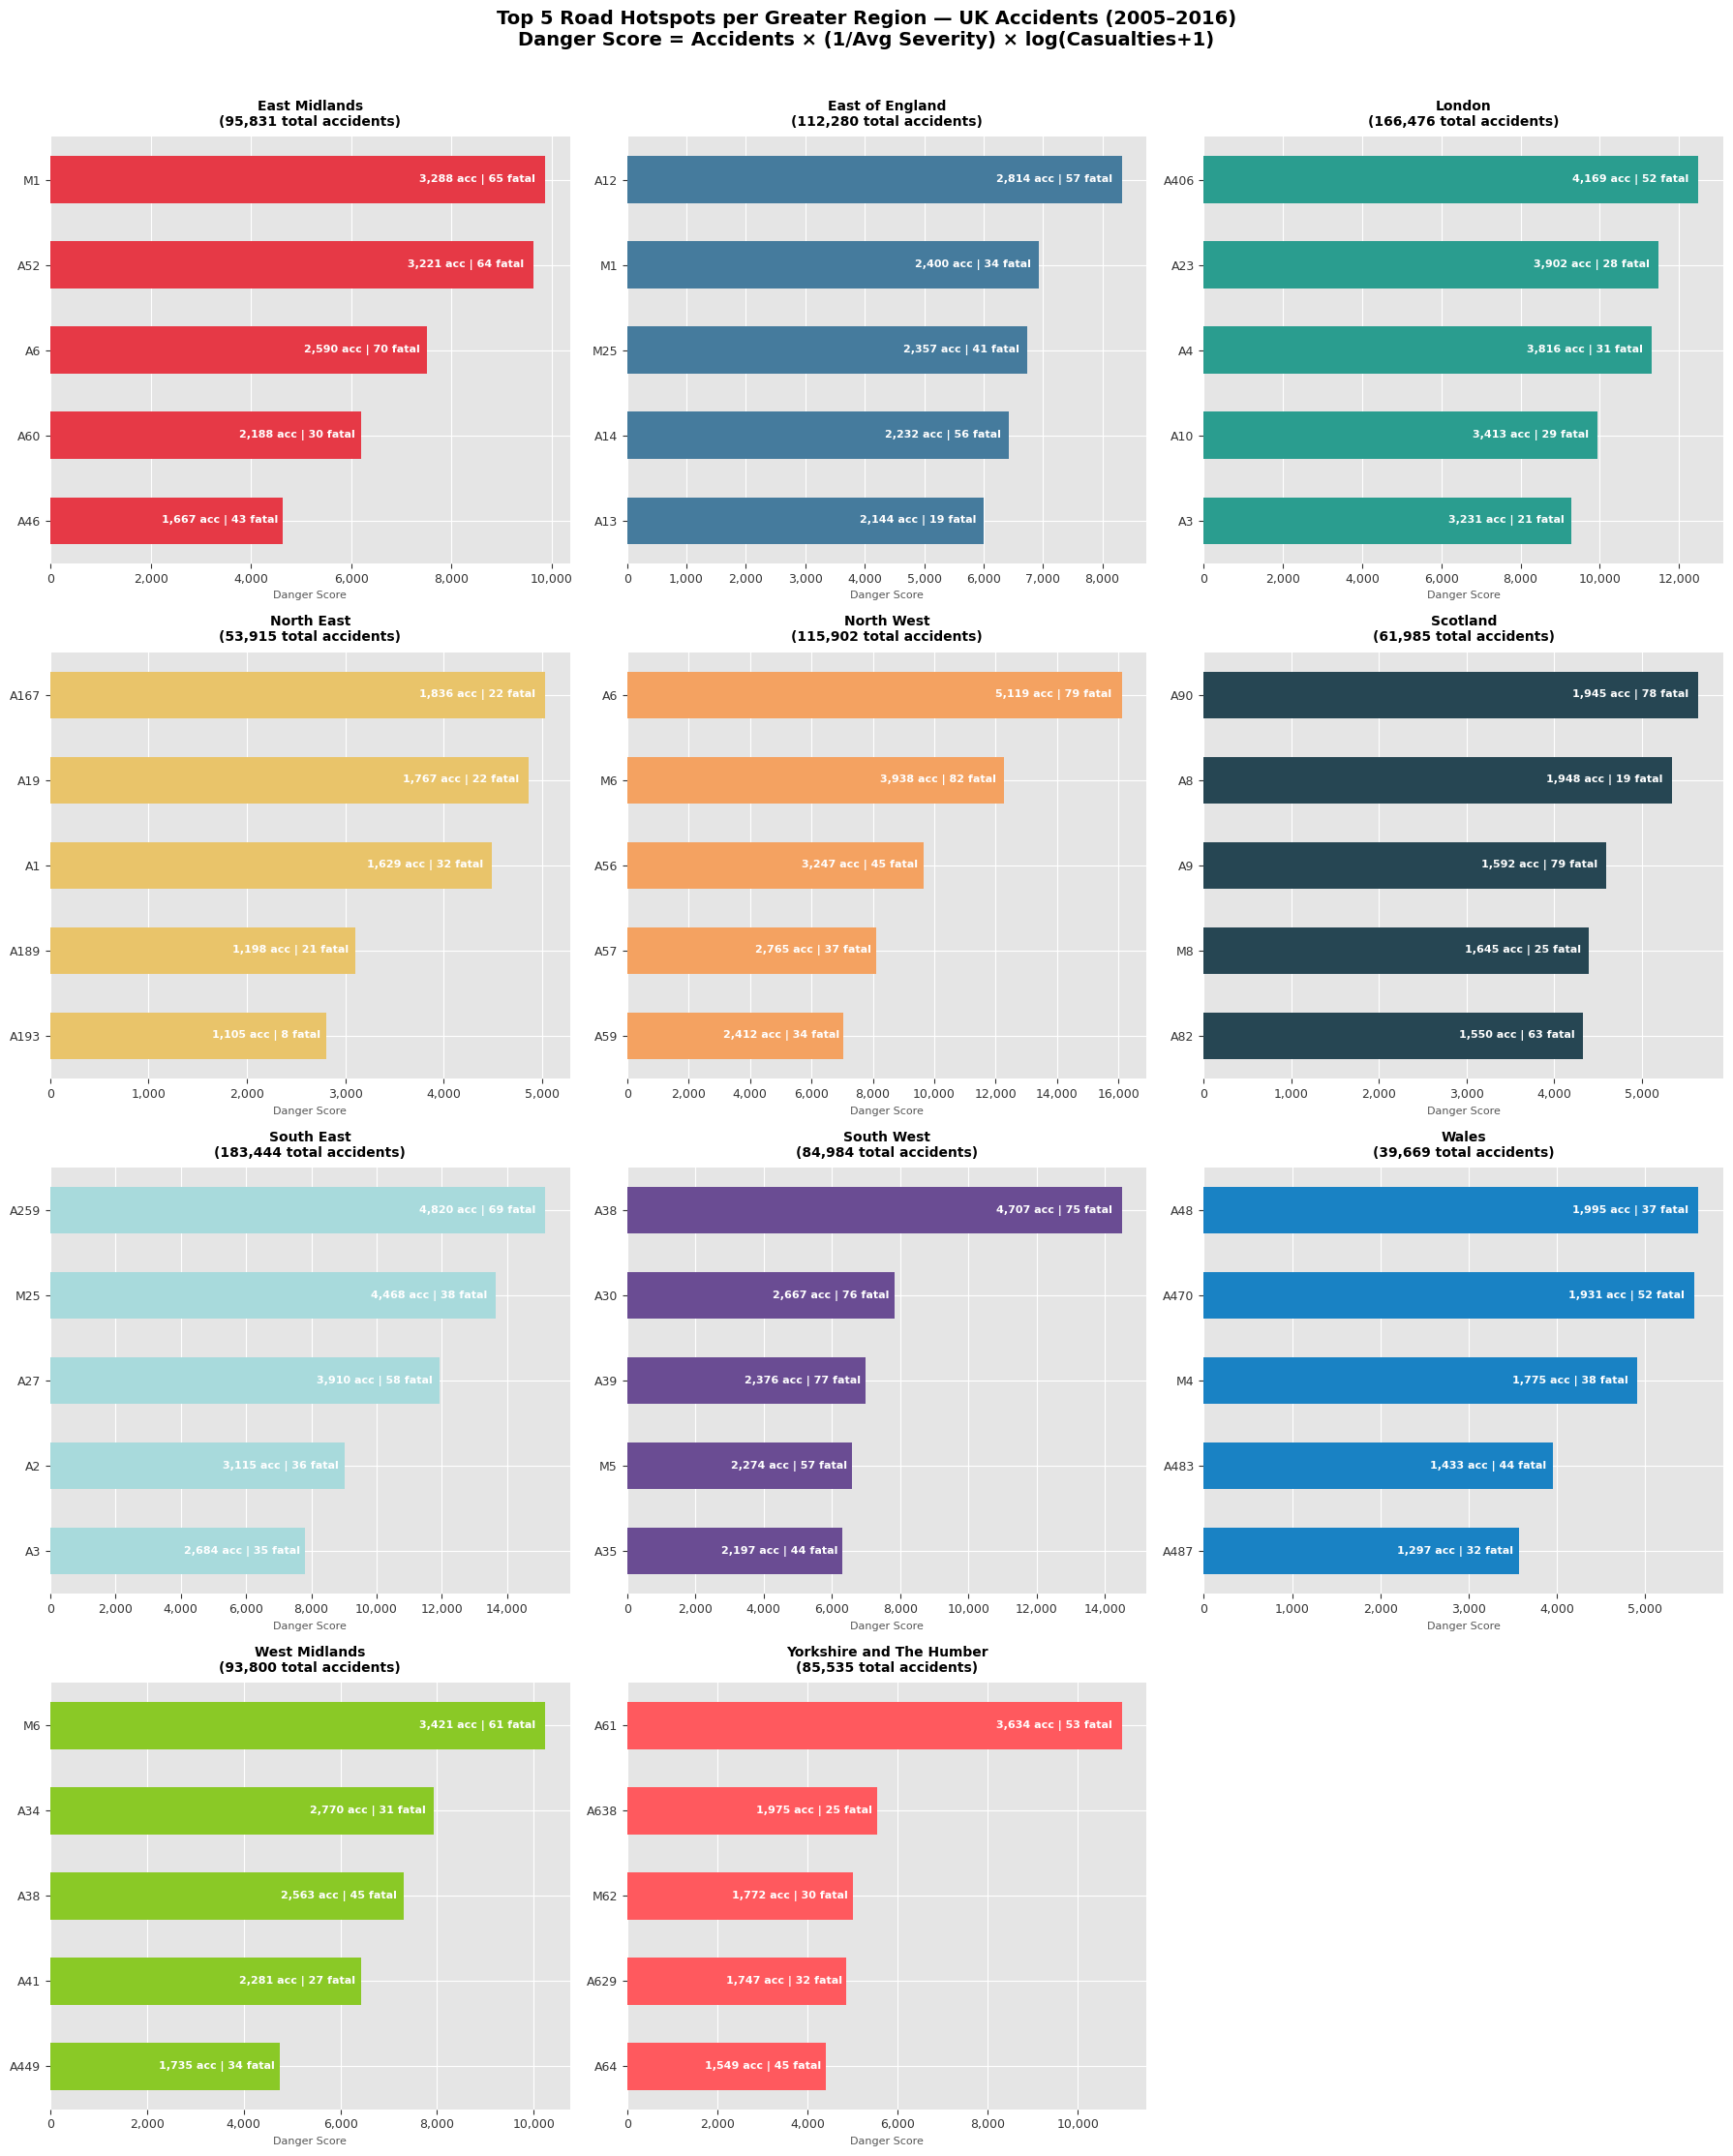

In [73]:
region_colors = {
    "East Midlands":             "#E63946",
    "East of England":           "#457B9D",
    "London":                    "#2A9D8F",
    "North East":                "#E9C46A",
    "North West":                "#F4A261",
    "Scotland":                  "#264653",
    "South East":                "#A8DADC",
    "South West":                "#6A4C93",
    "Wales":                     "#1982C4",
    "West Midlands":             "#8AC926",
    "Yorkshire and The Humber":  "#FF595E",
}

regions_sorted = sorted(top5["greater_region"].unique())

fig, axes = plt.subplots(
    nrows=4, ncols=3,
    figsize=(18, 22),
    facecolor="white"
)
axes = axes.flatten()

for i, region in enumerate(regions_sorted):
    ax = axes[i]
    df_r = top5[top5["greater_region"] == region].sort_values("danger_score")

    color = region_colors.get(region, "#888888")
    bars = ax.barh(
        df_r["road_id"],
        df_r["danger_score"],
        color=color,
        edgecolor="none",
        height=0.55,
    )

    for bar, (_, row) in zip(bars, df_r.iterrows()):
        ax.text(
            bar.get_width() * 0.98,
            bar.get_y() + bar.get_height() / 2,
            f"{row['total_accidents']:,} acc | {row['fatal_count']} fatal",
            va="center", ha="right",
            color="white", fontsize=8, fontweight="bold"
        )

    region_total = df_roads[df_roads["greater_region"] == region]["Accident_Index"].count()
    ax.set_title(
        f"{region}\n({region_total:,} total accidents)",
        fontsize=10, fontweight="bold", pad=8
    )
    ax.set_xlabel("Danger Score", fontsize=8, color="#555555")
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="#333333", labelsize=9)
    ax.set_xlim(0, df_r["danger_score"].max() * 1.05)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[-1].set_visible(False)

fig.suptitle(
    "Top 5 Road Hotspots per Greater Region — UK Accidents (2005–2016)\n"
    "Danger Score = Accidents × (1/Avg Severity) × log(Casualties+1)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

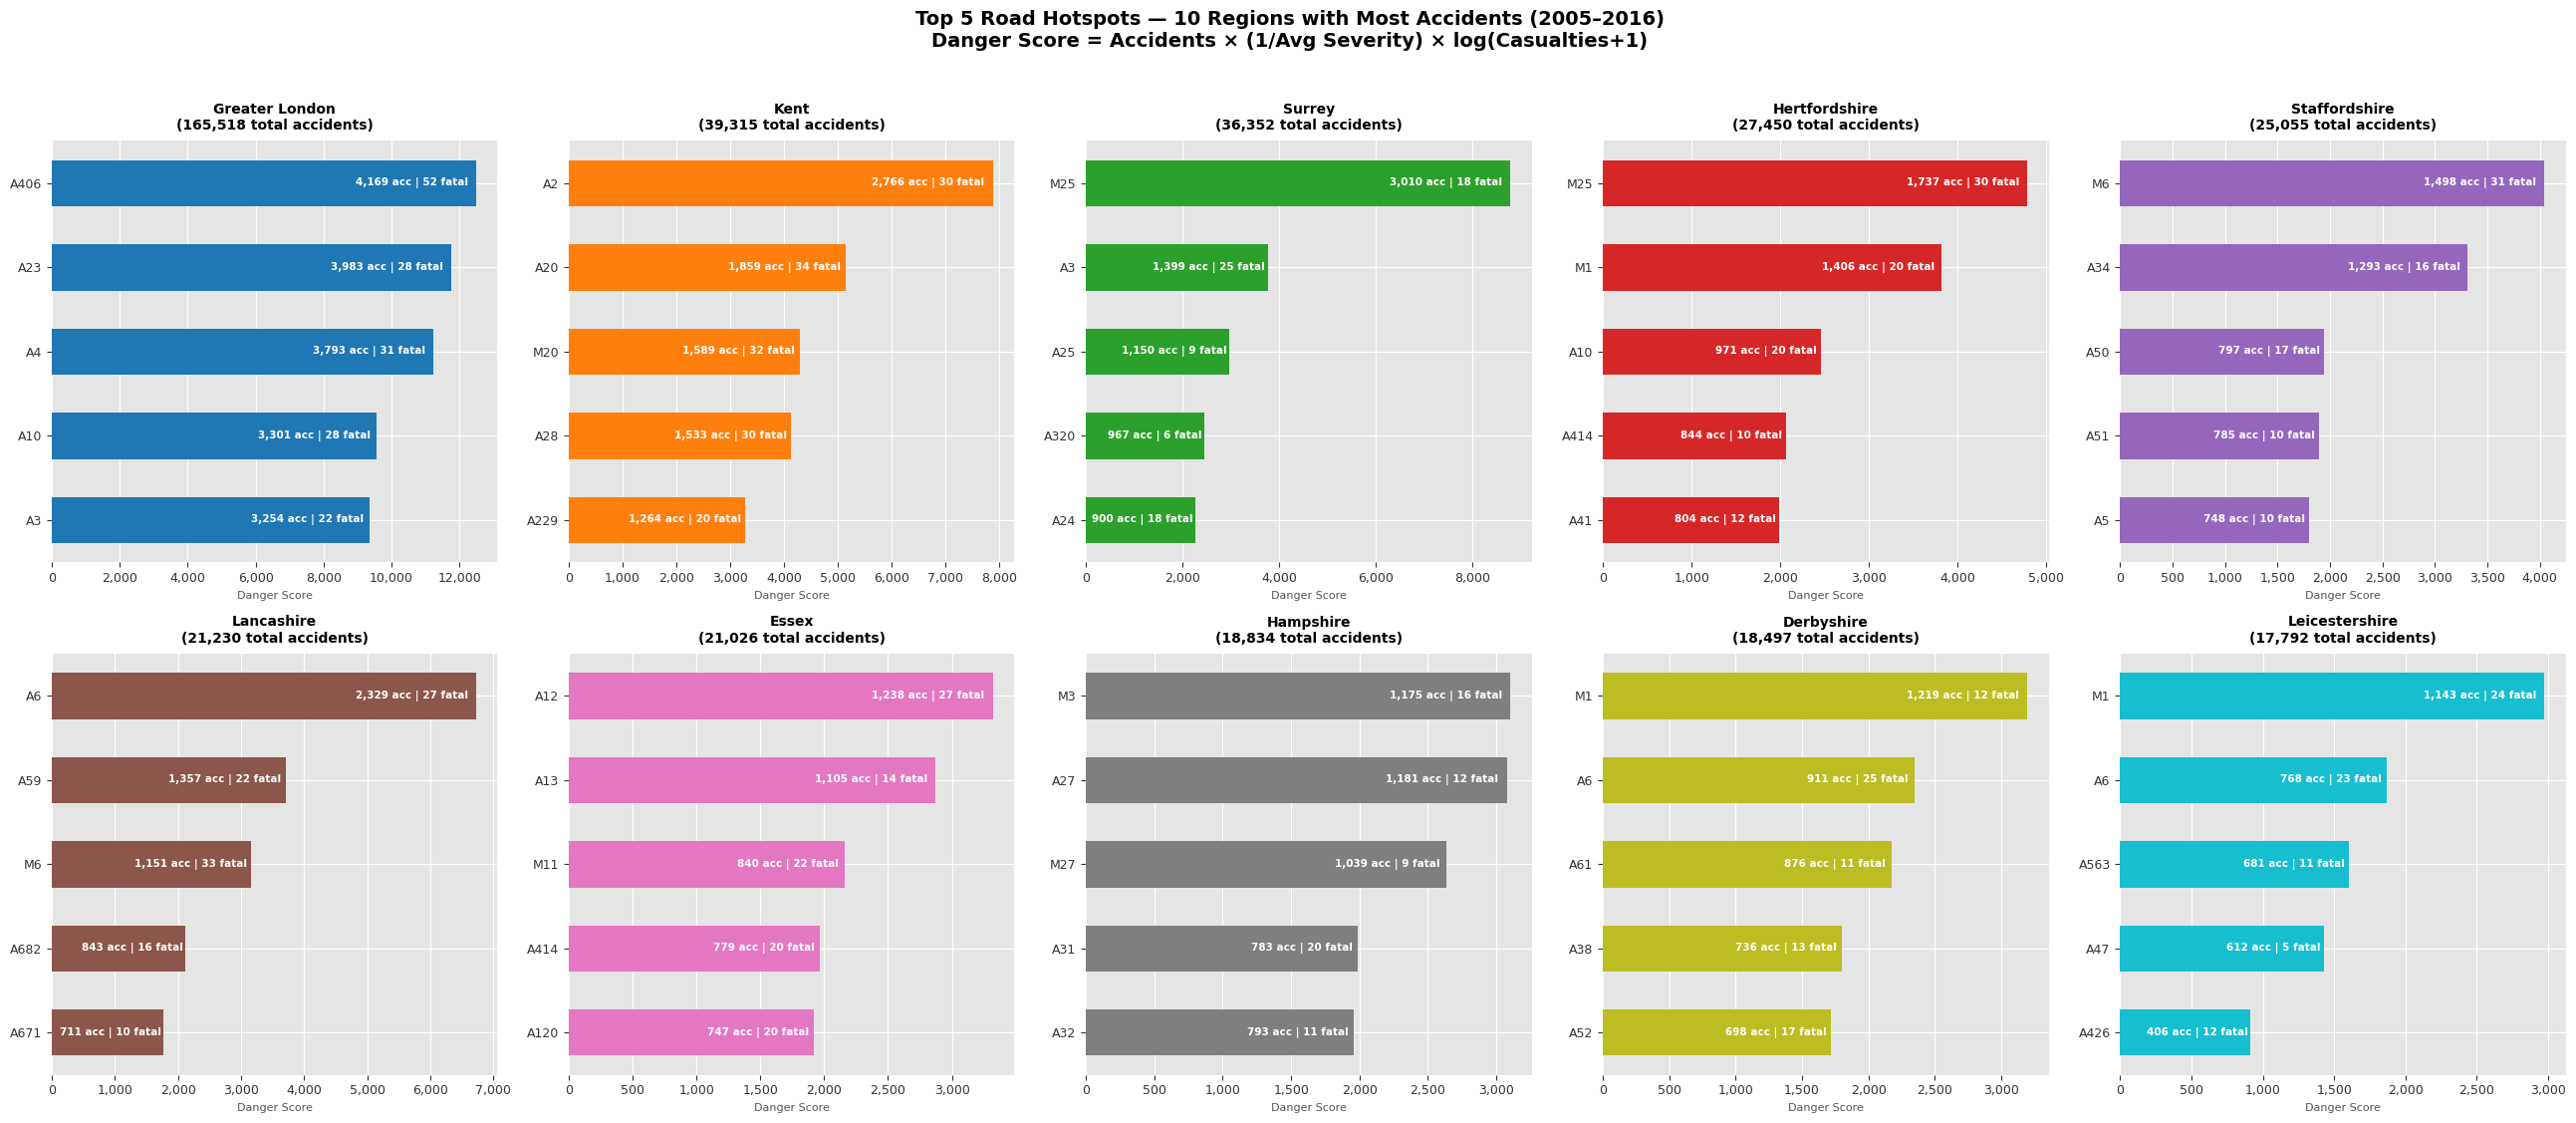

In [74]:
import matplotlib.cm as cm

hotspots_region = (
    df_roads.groupby(["region", "road_id"])
    .agg(
        total_accidents  = ("Accident_Index", "count"),
        avg_severity     = ("Accident_Severity", "mean"),
        total_casualties = ("Number_of_Casualties", "sum"),
        fatal_count      = ("Accident_Severity", lambda x: (x == 1).sum()),
    )
    .reset_index()
)

# Danger score
hotspots_region["danger_score"] = (
    hotspots_region["total_accidents"] *
    (1 / hotspots_region["avg_severity"]) *
    np.log1p(hotspots_region["total_casualties"])
).round(2)


top10_regions = (
    df_roads.groupby("region")["Accident_Index"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

top5_region = (
    hotspots_region.sort_values("danger_score", ascending=False)
    .groupby("region")
    .head(5)
    .sort_values(["region", "danger_score"], ascending=[True, False])
)

top5_top10 = top5_region[top5_region["region"].isin(top10_regions)].copy()

palette = [cm.tab10(i) for i in range(10)]
region_color_map = {r: palette[i] for i, r in enumerate(top10_regions)}

fig, axes = plt.subplots(
    nrows=2, ncols=5,
    figsize=(26, 11),
    facecolor="white"
)
axes = axes.flatten()

for i, region in enumerate(top10_regions):
    ax = axes[i]
    df_r = top5_top10[top5_top10["region"] == region].sort_values("danger_score")

    color = region_color_map.get(region, "#888888")
    bars = ax.barh(
        df_r["road_id"],
        df_r["danger_score"],
        color=color,
        edgecolor="none",
        height=0.55,
    )

    for bar, (_, row) in zip(bars, df_r.iterrows()):
        ax.text(
            bar.get_width() * 0.98,
            bar.get_y() + bar.get_height() / 2,
            f"{row['total_accidents']:,} acc | {row['fatal_count']} fatal",
            va="center", ha="right",
            color="white", fontsize=7.5, fontweight="bold"
        )

    region_total = df_roads[df_roads["region"] == region]["Accident_Index"].count()
    ax.set_title(
        f"{region}\n({region_total:,} total accidents)",
        fontsize=10, fontweight="bold", pad=8
    )
    ax.set_xlabel("Danger Score", fontsize=8, color="#555555")
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="#333333", labelsize=9)
    ax.set_xlim(0, df_r["danger_score"].max() * 1.05)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Top 5 Road Hotspots — 10 Regions with Most Accidents (2005–2016)\n"
    "Danger Score = Accidents × (1/Avg Severity) × log(Casualties+1)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()